In [38]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os.path as op

from specula.mmlib.compute_rec import rec_phot_cov, rec_ron_cov
from specula.mmlib.utils import get_pupil_mask, radial_order

root_dir = '/raid1/mmenessini/calibration/RISTRETTOunobs'

In [4]:
rMods = np.array([0,1,2,3])
n_subaps = np.array([12,16,24,48]) #np.array([16,24,48])
n_modes = np.array([50,150,300,600,1200]) #np.array([150,300,1300])
seeings = np.array([0.5,0.7,0.9,1.1,1.3,1.5]) #np.array([0.7,0.9,1.1])

In [47]:
def generate_psd(f, cutoff, power):
    f_safe = np.maximum(f, f[0])
    psd_turb = np.where(f_safe <= cutoff, 1.0, (f_safe / cutoff)**(-17/3))
    df = np.gradient(f)
    f_s = f[-1] * 2 
    sinc_filter = np.sinc(f_safe / f_s)**2 
    psd_turb *= sinc_filter
    psd_turb *= (power / np.sum(psd_turb * df))
    return psd_turb

22.098627
0.2513005616557969 3.504805211835419e-05 0.18509275 3.3735844558284115e-05


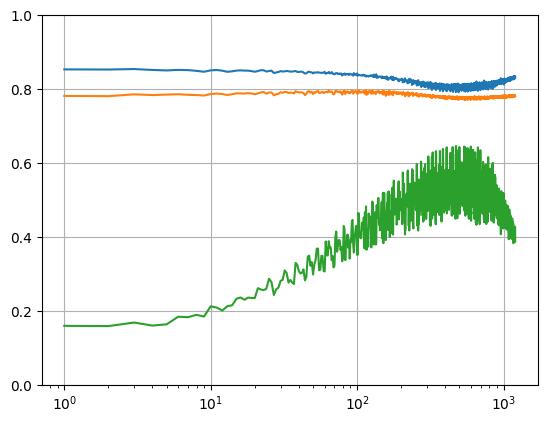

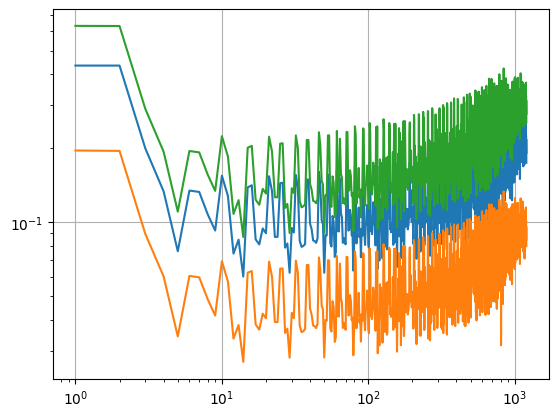

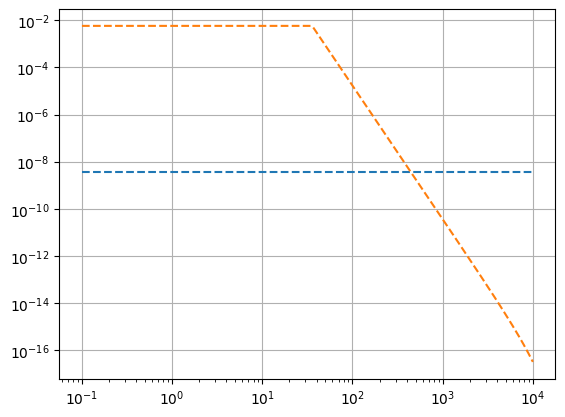

In [48]:
rMod = 1
n_subap = 48
seeing = 1.5
N = 1200
VoverD = 20/8.4

pyr_mask = get_pupil_mask(npix=120,filepath=op.join(root_dir,'pupils',f'pyr_pupdata_{n_subap:.0f}x{n_subap:.0f}.fits'))
frame = fits.getdata(op.join(root_dir,'frames',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_avg_frame.fits'))
sn = fits.getdata(op.join(root_dir,'slopenulls',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_sn.fits'))+2e-2
alias = fits.getdata(op.join(root_dir,'aliasing',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_alias.fits'))
rec = fits.getdata(op.join(root_dir,'rec',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_{N}modes_rec.fits'))
simpc = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_simpc.fits'))
simpc1 = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_1Nm_simpc.fits'))
simpc10 = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_10Nm_simpc.fits'))

og = np.diag(rec @ simpc)
og1 = np.diag(rec @ simpc1)
og10 = np.diag(rec @ simpc10)

RON = 0.5
Nphot = 1e+5
cutoff = 0.3*(radial_order(N)+1+1)*VoverD

ron_cov = rec_ron_cov(rec,frame,mask=pyr_mask)*RON/Nphot**2 
shot_cov = rec_phot_cov(rec,frame,mask=pyr_mask,sn=sn)/Nphot
cov = ron_cov + shot_cov

x = np.arange(len(alias))+1

print(np.sqrt(np.sum(alias**2)))

plt.figure()
# plt.semilogx(x,alias)
plt.semilogx(x,og)
plt.semilogx(x,og1)
plt.semilogx(x,og10)
plt.ylim([0,1])
plt.grid()

plt.figure()
plt.loglog(x,ron_cov)
plt.loglog(x,shot_cov)
plt.loglog(x,cov)
plt.grid()

idx = 10
f = np.logspace(-1,4,200)
alias_psd = generate_psd(f,cutoff,power=alias[idx]**2)
noise_psd = np.ones_like(f)
noise_psd *= cov[idx]/(np.sum(f * np.gradient(f)))

plt.figure()
plt.loglog(f,noise_psd,'--')
plt.loglog(f,alias_psd,'--')
plt.grid()

print(np.trapezoid(alias_psd,f),np.trapezoid(noise_psd,f),cov[idx],alias_psd[idx]**2)